In [2]:
# ============================================================
# BLOCK 1 — Imports
# ============================================================
import shap
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import re
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

print(f"SHAP version : {shap.__version__}")
print("All imports successful")

SHAP version : 0.51.0
All imports successful


In [3]:
# ============================================================
# BLOCK 2 — Load Saved Models
# ============================================================
with open('models/svm_model.pkl', 'rb') as f:
    svm_calibrated = pickle.load(f)

with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('models/robust_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("✓ SVM model loaded")
print("✓ TF-IDF vectorizer loaded")
print("✓ RobustScaler loaded")

# Verify models folder
print("\nAll files in models folder:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f"  {f:<40} {size:.2f} MB")

✓ SVM model loaded
✓ TF-IDF vectorizer loaded
✓ RobustScaler loaded

All files in models folder:
  .ipynb_checkpoints                       0.00 MB
  bert_base                                0.00 MB
  bert_classifier.pt                       418.47 MB
  bert_tokenizer                           0.00 MB
  lstm_model.pt                            13.48 MB
  rf_model.pkl                             67.12 MB
  robust_scaler.pkl                        0.00 MB
  robust_scaler_bert.pkl                   0.00 MB
  svm_model.pkl                            1.15 MB
  tfidf_vectorizer.pkl                     1.97 MB
  Untitled.ipynb                           0.00 MB


In [4]:
# ============================================================
# BLOCK 3 — Load + Preprocess Data
# ============================================================
df_train = pd.read_csv("train.csv")
df_valid = pd.read_csv("valid.csv")
df_test  = pd.read_csv("test.csv")

# Column cleanup
cols_to_drop = ['id', 'date', 'state_info', 'speaker_description']
for df in [df_train, df_valid, df_test]:
    df.drop(columns=cols_to_drop, inplace=True)
    df['subject'] = df['subject'].where(df['subject'].notna(),
                                         other='unknown')
    df['context'] = df['context'].where(df['context'].notna(),
                                         other='unknown')

# Binary labels
def to_binary(label):
    return 0 if label in [0, 1, 2] else 1

y_train = df_train['label'].apply(to_binary).values
y_valid = df_valid['label'].apply(to_binary).values
y_test  = df_test['label'].apply(to_binary).values

# Credibility ratios
credit_cols = ['true_counts', 'mostly_true_counts', 'half_true_counts',
               'mostly_false_counts', 'false_counts',
               'pants_on_fire_counts']
for df in [df_train, df_valid, df_test]:
    df['total_counts'] = df[credit_cols].sum(axis=1)

ratio_cols = []
for col in credit_cols:
    ratio_col = col.replace('_counts', '_ratio')
    for df in [df_train, df_valid, df_test]:
        df[ratio_col] = df[col] / df['total_counts']
    ratio_cols.append(ratio_col)

# Use transform only — scaler already fitted on train
X_train_meta = scaler.transform(df_train[ratio_cols])
X_valid_meta  = scaler.transform(df_valid[ratio_cols])
X_test_meta   = scaler.transform(df_test[ratio_cols])

# Text cleaning
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+', '', text)
    text   = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words]
    return ' '.join(tokens)

print("Cleaning text — this takes 2-3 minutes...")
for df in [df_train, df_valid, df_test]:
    df['clean_statement']     = df['statement'].apply(clean_text)
    df['clean_justification'] = df['justification'].apply(clean_text)
    df['combined_text']       = (df['clean_statement'] + ' ' +
                                  df['clean_justification'])

# TF-IDF transform only — vectorizer already fitted on train
X_train_tfidf = tfidf.transform(df_train['combined_text'])
X_valid_tfidf = tfidf.transform(df_valid['combined_text'])
X_test_tfidf  = tfidf.transform(df_test['combined_text'])

# Final feature matrices
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_valid_final = hstack([X_valid_tfidf, csr_matrix(X_valid_meta)])
X_test_final  = hstack([X_test_tfidf,  csr_matrix(X_test_meta)])

print("✓ Data loaded and preprocessed")
print(f"✓ X_test_final shape  : {X_test_final.shape}")
print(f"✓ y_test samples      : {len(y_test)}")

Cleaning text — this takes 2-3 minutes...
✓ Data loaded and preprocessed
✓ X_test_final shape  : (2296, 50006)
✓ y_test samples      : 2296


In [5]:
# ============================================================
# BLOCK 4 — Feature Names
# ============================================================
tfidf_feature_names = tfidf.get_feature_names_out().tolist()
meta_feature_names  = [
    'true_ratio', 'mostly_true_ratio',  'half_true_ratio',
    'mostly_false_ratio', 'false_ratio', 'pants_on_fire_ratio'
]
all_feature_names = tfidf_feature_names + meta_feature_names

print(f"TF-IDF features : {len(tfidf_feature_names):,}")
print(f"Meta features   : {len(meta_feature_names)}")
print(f"Total features  : {len(all_feature_names):,}")
print(f"\nSample TF-IDF   : {tfidf_feature_names[:5]}")
print(f"Meta features   : {meta_feature_names}")

TF-IDF features : 50,000
Meta features   : 6
Total features  : 50,006

Sample TF-IDF   : ['aa', 'aaa', 'aaa credit', 'aaron', 'aaron death']
Meta features   : ['true_ratio', 'mostly_true_ratio', 'half_true_ratio', 'mostly_false_ratio', 'false_ratio', 'pants_on_fire_ratio']


In [6]:
# ============================================================
# BLOCK 5 — Build SHAP Explainer + Compute SHAP Values
# ============================================================
# Sample 500 background + 200 explain samples
np.random.seed(42)
background_idx = np.random.choice(X_train_final.shape[0],
                                   500, replace=False)
explain_idx    = np.random.choice(X_test_final.shape[0],
                                   200, replace=False)

X_background = X_train_final[background_idx]
X_explain    = X_test_final[explain_idx]
y_explain    = y_test[explain_idx]

print(f"Background samples : {X_background.shape[0]}")
print(f"Samples to explain : {X_explain.shape[0]}")

# Build explainer
print("\nBuilding SHAP explainer...")
explainer = shap.KernelExplainer(
    svm_calibrated.predict_proba,
    X_background,
    link='logit'
)
print("Explainer ready")

# Compute SHAP values
# WARNING — this takes 10-20 minutes on CPU
# Do NOT interrupt — saved to disk after completion
print("\nComputing SHAP values...")
print("Expected time: 10-20 minutes on CPU — let it run...\n")
start = time.time()

shap_values = explainer.shap_values(
    X_explain,
    nsamples=100,
    silent=False
)

elapsed = time.time() - start
print(f"\n✓ SHAP values computed in {elapsed/60:.1f} minutes")
print(f"Shape (class 0 — Fake): {np.array(shap_values[0]).shape}")
print(f"Shape (class 1 — Real): {np.array(shap_values[1]).shape}")

# Save immediately so you never recompute
os.makedirs('models', exist_ok=True)
with open('models/shap_values.pkl', 'wb') as f:
    pickle.dump({
        'shap_values' : shap_values,
        'X_explain'   : X_explain,
        'y_explain'   : y_explain,
        'explain_idx' : explain_idx
    }, f)
print("✓ SHAP values saved to models/shap_values.pkl")

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Background samples : 500
Samples to explain : 200

Building SHAP explainer...
Explainer ready

Computing SHAP values...
Expected time: 10-20 minutes on CPU — let it run...



100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [1:11:32<00:00, 21.46s/it]



✓ SHAP values computed in 71.5 minutes
Shape (class 0 — Fake): (50006, 2)
Shape (class 1 — Real): (50006, 2)
✓ SHAP values saved to models/shap_values.pkl


In [9]:
import numpy as np
import pickle

# Check exact structure
print("Type of shap_values      :", type(shap_values))
print("Length of shap_values    :", len(shap_values))
print()

for i, sv in enumerate(shap_values):
    print(f"shap_values[{i}] type  : {type(sv)}")
    print(f"shap_values[{i}] shape : {np.array(sv).shape}")
    print()

# Also check the saved file
with open('models/shap_values.pkl', 'rb') as f:
    saved = pickle.load(f)

print("Keys in saved file:", list(saved.keys()))
print("Saved shap_values type  :", type(saved['shap_values']))
print("Saved shap_values length:", len(saved['shap_values']))

Type of shap_values      : <class 'numpy.ndarray'>
Length of shap_values    : 200

shap_values[0] type  : <class 'numpy.ndarray'>
shap_values[0] shape : (50006, 2)

shap_values[1] type  : <class 'numpy.ndarray'>
shap_values[1] shape : (50006, 2)

shap_values[2] type  : <class 'numpy.ndarray'>
shap_values[2] shape : (50006, 2)

shap_values[3] type  : <class 'numpy.ndarray'>
shap_values[3] shape : (50006, 2)

shap_values[4] type  : <class 'numpy.ndarray'>
shap_values[4] shape : (50006, 2)

shap_values[5] type  : <class 'numpy.ndarray'>
shap_values[5] shape : (50006, 2)

shap_values[6] type  : <class 'numpy.ndarray'>
shap_values[6] shape : (50006, 2)

shap_values[7] type  : <class 'numpy.ndarray'>
shap_values[7] shape : (50006, 2)

shap_values[8] type  : <class 'numpy.ndarray'>
shap_values[8] shape : (50006, 2)

shap_values[9] type  : <class 'numpy.ndarray'>
shap_values[9] shape : (50006, 2)

shap_values[10] type  : <class 'numpy.ndarray'>
shap_values[10] shape : (50006, 2)

shap_values[1

In [10]:
# ============================================================
# FIX — Reshape SHAP values to correct format
# ============================================================
# Current shape: (200, 50006, 2)
# We need:
#   shap_fake : (200, 50006) — contributions toward Fake
#   shap_real : (200, 50006) — contributions toward Real

shap_array = np.array(shap_values)  # (200, 50006, 2)

print(f"Full array shape : {shap_array.shape}")

shap_fake = shap_array[:, :, 0]    # all samples, all features, class 0
shap_real = shap_array[:, :, 1]    # all samples, all features, class 1

print(f"shap_fake shape  : {shap_fake.shape}")  # (200, 50006)
print(f"shap_real shape  : {shap_real.shape}")  # (200, 50006)
print("Reshape successful")

Full array shape : (200, 50006, 2)
shap_fake shape  : (200, 50006)
shap_real shape  : (200, 50006)
Reshape successful


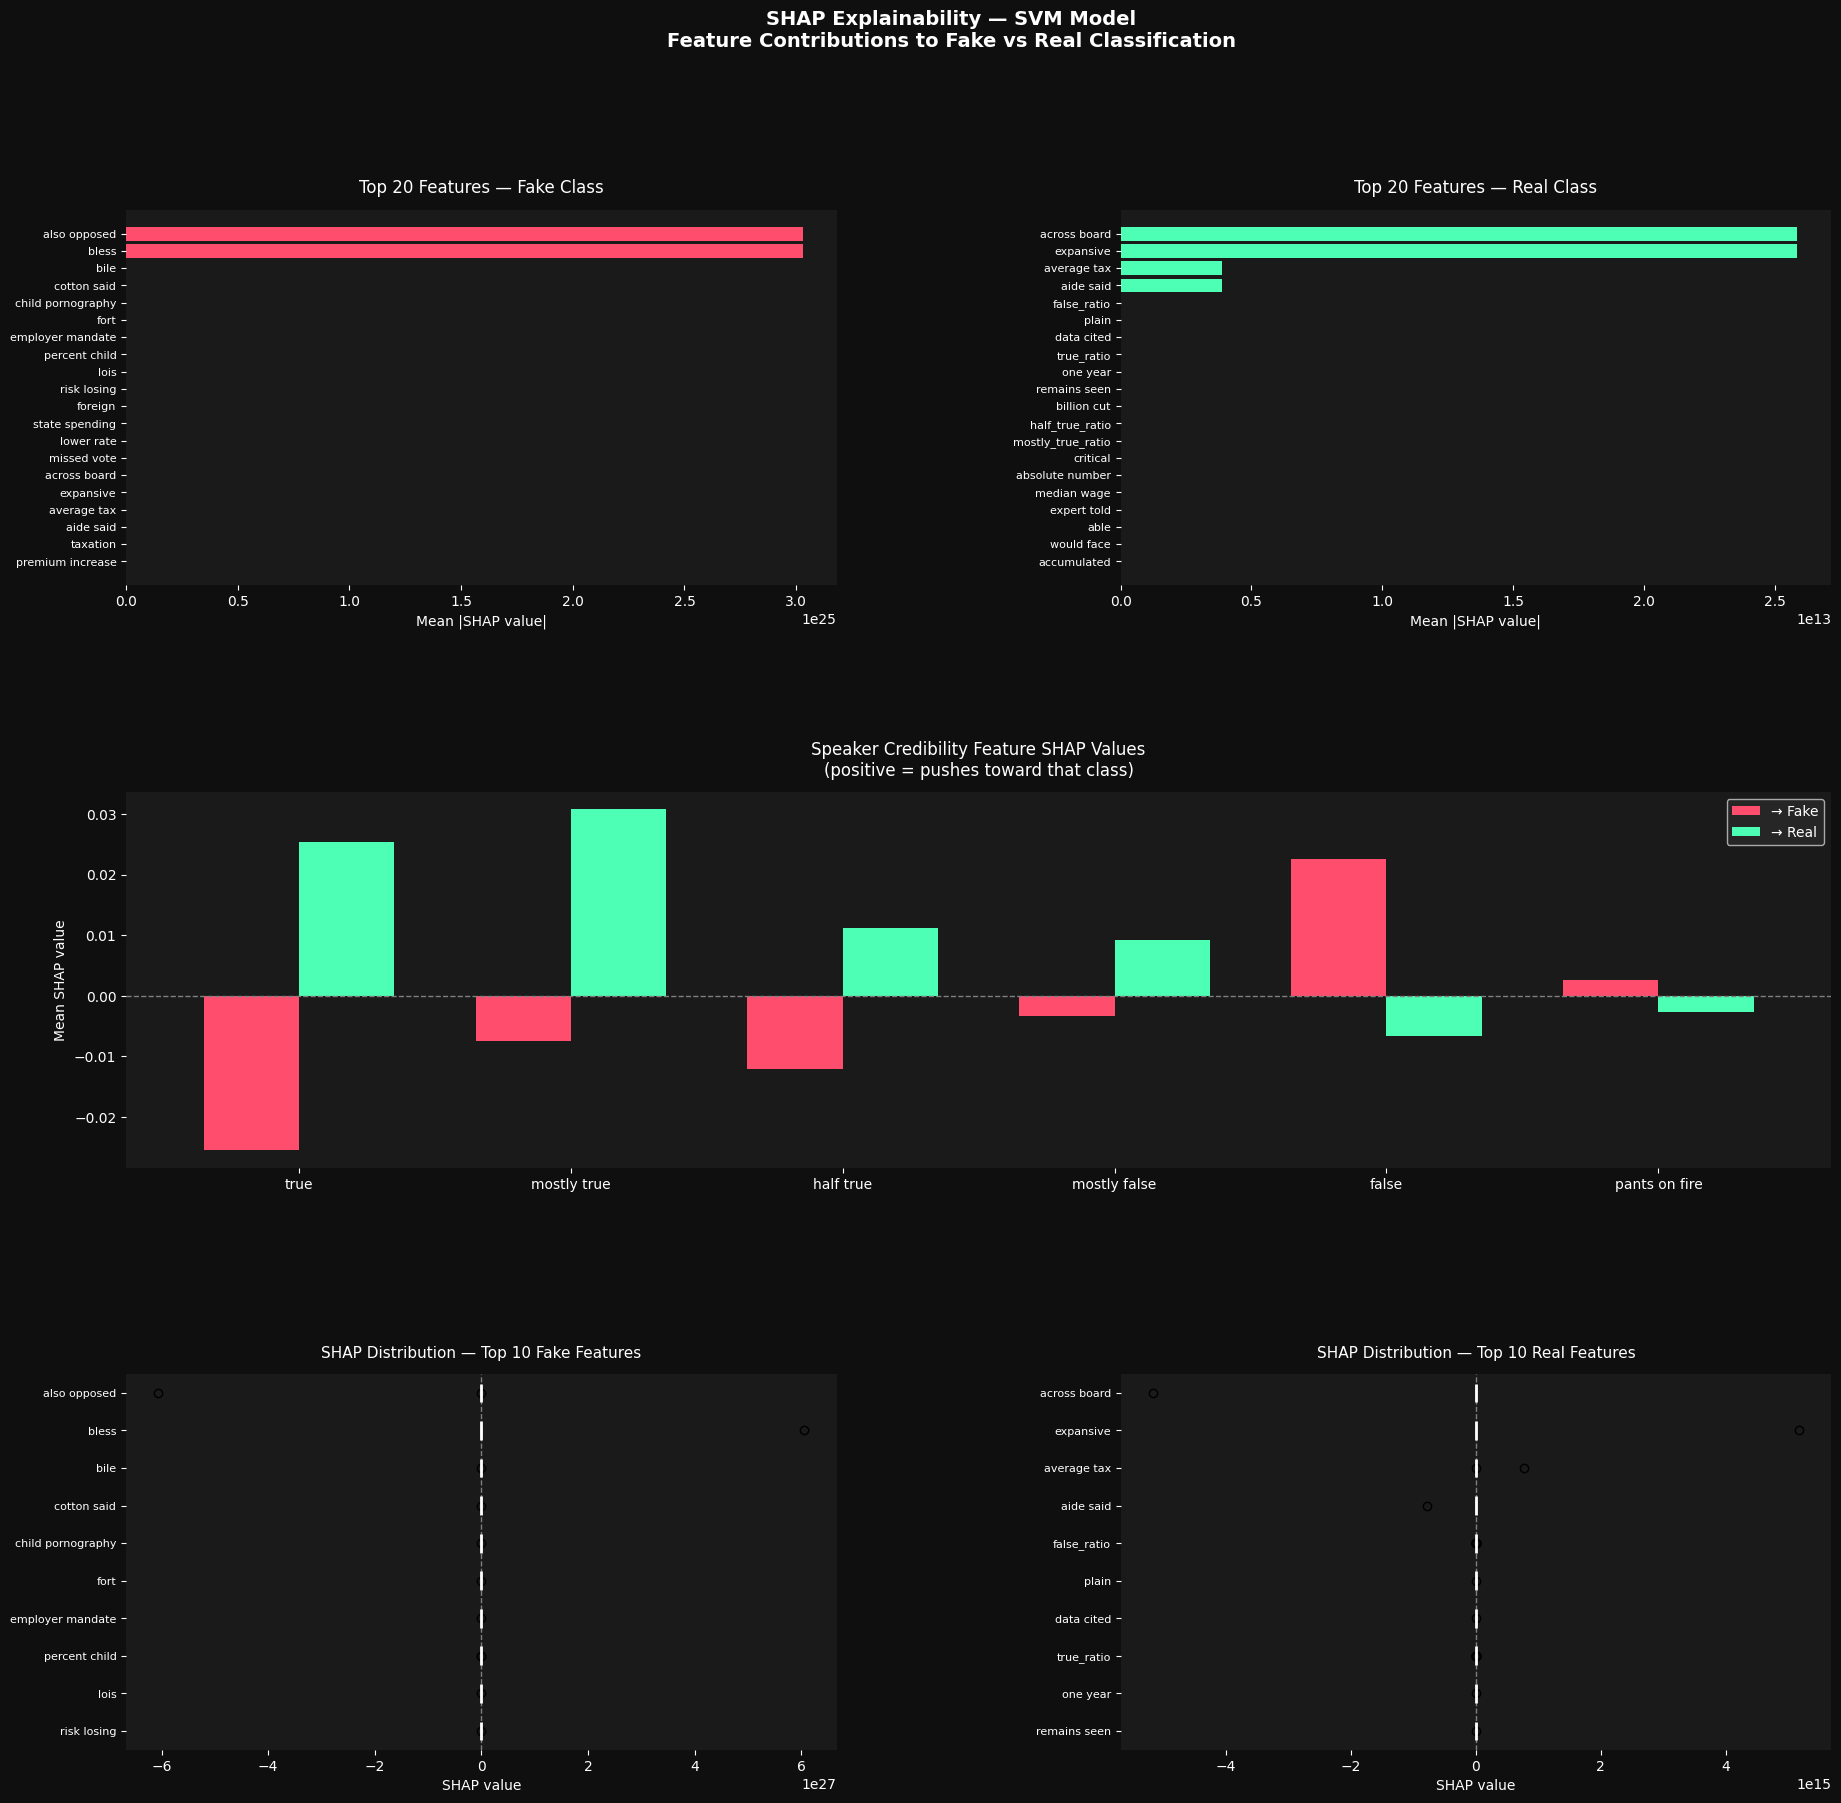

In [12]:
# ============================================================
# BLOCK 7 — Global SHAP Visuals (Fixed)
# ============================================================
TOP_N = 20

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor('#0f0f0f')
gs  = gridspec.GridSpec(3, 2, figure=fig,
                         hspace=0.55, wspace=0.4)

# -- Plot 1: Top features → Fake -----------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a1a1a')
mean_shap_fake = np.abs(shap_fake).mean(axis=0)  # (50006,)
top_fake_idx   = np.argsort(mean_shap_fake)[-TOP_N:]
top_fake_names = [all_feature_names[i] for i in top_fake_idx]
top_fake_vals  = mean_shap_fake[top_fake_idx]
ax1.barh(range(TOP_N), top_fake_vals,
          color='#ff4d6d', edgecolor='none')
ax1.set_yticks(range(TOP_N))
ax1.set_yticklabels(top_fake_names, fontsize=8, color='white')
ax1.set_title(f'Top {TOP_N} Features — Fake Class',
              color='white', fontsize=12, pad=12)
ax1.set_xlabel('Mean |SHAP value|', color='white')
ax1.tick_params(colors='white')
ax1.spines[:].set_visible(False)

# -- Plot 2: Top features → Real -----------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1a1a1a')
mean_shap_real = np.abs(shap_real).mean(axis=0)  # (50006,)
top_real_idx   = np.argsort(mean_shap_real)[-TOP_N:]
top_real_names = [all_feature_names[i] for i in top_real_idx]
top_real_vals  = mean_shap_real[top_real_idx]
ax2.barh(range(TOP_N), top_real_vals,
          color='#4dffb4', edgecolor='none')
ax2.set_yticks(range(TOP_N))
ax2.set_yticklabels(top_real_names, fontsize=8, color='white')
ax2.set_title(f'Top {TOP_N} Features — Real Class',
              color='white', fontsize=12, pad=12)
ax2.set_xlabel('Mean |SHAP value|', color='white')
ax2.tick_params(colors='white')
ax2.spines[:].set_visible(False)

# -- Plot 3: Credibility features Fake vs Real ---------------
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#1a1a1a')
meta_start     = len(tfidf_feature_names)
meta_shap_fake = shap_fake[:, meta_start:].mean(axis=0)  # (6,)
meta_shap_real = shap_real[:, meta_start:].mean(axis=0)  # (6,)
x     = np.arange(len(meta_feature_names))
width = 0.35
ax3.bar(x - width/2, meta_shap_fake, width,
        color='#ff4d6d', label='→ Fake', edgecolor='none')
ax3.bar(x + width/2, meta_shap_real, width,
        color='#4dffb4', label='→ Real', edgecolor='none')
ax3.axhline(0, color='gray', lw=1, linestyle='--')
ax3.set_xticks(x)
ax3.set_xticklabels(
    [m.replace('_ratio','').replace('_',' ')
     for m in meta_feature_names],
    color='white', fontsize=10)
ax3.set_title('Speaker Credibility Feature SHAP Values\n'
              '(positive = pushes toward that class)',
              color='white', fontsize=12, pad=12)
ax3.set_ylabel('Mean SHAP value', color='white')
ax3.legend(facecolor='#2a2a2a', labelcolor='white')
ax3.tick_params(colors='white')
ax3.spines[:].set_visible(False)

# -- Plot 4: SHAP distribution — Fake top 10 ----------------
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor('#1a1a1a')
top10_fake_idx   = np.argsort(mean_shap_fake)[-10:]
top10_fake_data  = shap_fake[:, top10_fake_idx]  # (200, 10)
top10_fake_names = [all_feature_names[i] for i in top10_fake_idx]
bp = ax4.boxplot(top10_fake_data, vert=False,
                  patch_artist=True,
                  medianprops=dict(color='white', lw=2))
for patch in bp['boxes']:
    patch.set_facecolor('#ff4d6d')
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#ff4d6d')
ax4.set_yticks(range(1, 11))
ax4.set_yticklabels(top10_fake_names, fontsize=8, color='white')
ax4.set_title('SHAP Distribution — Top 10 Fake Features',
              color='white', fontsize=11, pad=12)
ax4.set_xlabel('SHAP value', color='white')
ax4.axvline(0, color='gray', lw=1, linestyle='--')
ax4.tick_params(colors='white')
ax4.spines[:].set_visible(False)

# -- Plot 5: SHAP distribution — Real top 10 ----------------
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor('#1a1a1a')
top10_real_idx   = np.argsort(mean_shap_real)[-10:]
top10_real_data  = shap_real[:, top10_real_idx]  # (200, 10)
top10_real_names = [all_feature_names[i] for i in top10_real_idx]
bp2 = ax5.boxplot(top10_real_data, vert=False,
                   patch_artist=True,
                   medianprops=dict(color='white', lw=2))
for patch in bp2['boxes']:
    patch.set_facecolor('#4dffb4')
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp2[element]:
        item.set_color('#4dffb4')
ax5.set_yticks(range(1, 11))
ax5.set_yticklabels(top10_real_names, fontsize=8, color='white')
ax5.set_title('SHAP Distribution — Top 10 Real Features',
              color='white', fontsize=11, pad=12)
ax5.set_xlabel('SHAP value', color='white')
ax5.axvline(0, color='gray', lw=1, linestyle='--')
ax5.tick_params(colors='white')
ax5.spines[:].set_visible(False)

plt.suptitle('SHAP Explainability — SVM Model\n'
             'Feature Contributions to Fake vs Real Classification',
             color='white', fontsize=14, fontweight='bold')

plt.show()

SINGLE PREDICTION EXPLANATION
Text (first 200 chars) : say sen mark pryor voted special subsidy lawmaker staff congress theyre protected obamacare cotton said pryor voted special subsidy lawmaker staff congress theyre protected obamacare subsidy referred ...
True label             : Fake
Predicted label        : Fake
Correct prediction     : True

Top 10 features SUPPORTING 'Fake':
  reporter lab                   SHAP = +1.2866
  one man                        SHAP = +1.0877
  burr                           SHAP = +0.8977
  wrote                          SHAP = +0.8582
  people got                     SHAP = +0.7131
  fox news                       SHAP = +0.2729
  mostly_false_ratio             SHAP = +0.0000
  true_ratio                     SHAP = +0.0000
  zuckerman                      SHAP = +0.0000
  zuckerbergs                    SHAP = +0.0000

Top 10 features OPPOSING 'Fake':
  shelf                          SHAP = -1.6605
  energy                         SHAP = -1.6570
  aa 

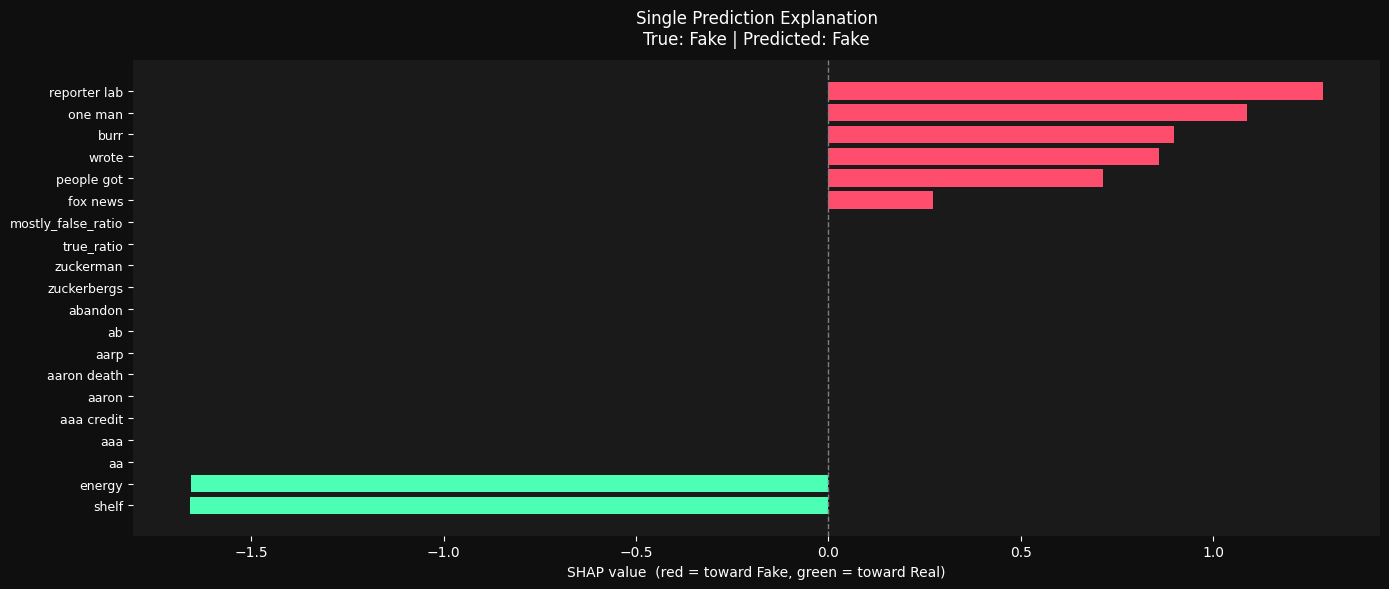

In [14]:
# ============================================================
# BLOCK 8 — Single Prediction Explanation (Fixed)
# ============================================================
sample_idx  = 0
sample_pred = svm_calibrated.predict(X_explain[sample_idx])[0]
sample_true = y_explain[sample_idx]
sample_text = df_test['combined_text'].iloc[explain_idx[sample_idx]]
pred_label  = 'Real' if sample_pred == 1 else 'Fake'
true_label  = 'Real' if sample_true == 1 else 'Fake'

print("="*60)
print("SINGLE PREDICTION EXPLANATION")
print("="*60)
print(f"Text (first 200 chars) : {sample_text[:200]}...")
print(f"True label             : {true_label}")
print(f"Predicted label        : {pred_label}")
print(f"Correct prediction     : {sample_pred == sample_true}")

# Extract SHAP values for this sample and predicted class
# shap_fake[sample_idx] or shap_real[sample_idx]
if sample_pred == 0:
    sample_shap = shap_fake[sample_idx]   # (50006,)
else:
    sample_shap = shap_real[sample_idx]   # (50006,)

top_pos_idx = np.argsort(sample_shap)[-10:]   # supporting pred
top_neg_idx = np.argsort(sample_shap)[:10]    # opposing pred

print(f"\nTop 10 features SUPPORTING '{pred_label}':")
for i in reversed(top_pos_idx):
    print(f"  {all_feature_names[i]:<30} "
          f"SHAP = {sample_shap[i]:+.4f}")

print(f"\nTop 10 features OPPOSING '{pred_label}':")
for i in top_neg_idx:
    print(f"  {all_feature_names[i]:<30} "
          f"SHAP = {sample_shap[i]:+.4f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')
all_top_idx   = list(top_neg_idx) + list(top_pos_idx)
all_top_vals  = [sample_shap[i] for i in all_top_idx]
all_top_names = [all_feature_names[i] for i in all_top_idx]
colors = ['#ff4d6d' if v > 0 else '#4dffb4' for v in all_top_vals]
ax.barh(range(len(all_top_idx)), all_top_vals,
         color=colors, edgecolor='none')
ax.set_yticks(range(len(all_top_idx)))
ax.set_yticklabels(all_top_names, fontsize=9, color='white')
ax.axvline(0, color='gray', lw=1, linestyle='--')
ax.set_title(f'Single Prediction Explanation\n'
             f'True: {true_label} | Predicted: {pred_label}',
             color='white', fontsize=12, pad=12)
ax.set_xlabel(
    'SHAP value  (red = toward Fake, green = toward Real)',
    color='white')
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()